# Diarization

In [1]:
!nvidia-smi

Wed Jun 24 20:30:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Setup and config

In [2]:
%%capture
%pip install -q uv

import subprocess
import sys

subprocess.run([
    "uv", "pip", "install", "--python", sys.executable,
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "torch==2.5.1", "torchvision==0.20.1", "torchaudio==2.5.1",
], check=True)

subprocess.run([
    "uv", "pip", "install", "--python", sys.executable,
    "--reinstall-package", "huggingface-hub",
    "--reinstall-package", "transformers",
    "huggingface-hub==0.36.0", "transformers==4.48.3",
    "datasets==3.6.0", "pandas==2.2.2",
    "lightning==2.5.2", "torchmetrics==1.7.1",
    "pyannote.audio==3.3.2", "pyannote.core==5.0.0",
    "pyannote.database==5.1.3", "pyannote.metrics==3.2.1",
    "pyannote.pipeline==3.0.1", "seaborn==0.13.2",
], check=True)

In [3]:
import os
import sys
from pathlib import Path

IN_KAGGLE = Path("/kaggle/working").exists()
IN_COLAB = Path("/content").exists() and not IN_KAGGLE

USE_GOOGLE_DRIVE = True

if IN_KAGGLE:
    PLATFORM = "kaggle"
    WORK_DIR = Path("/kaggle/working/audio_curse_option2")

elif IN_COLAB:
    PLATFORM = "colab"

    if USE_GOOGLE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        WORK_DIR = Path("/content/drive/MyDrive/audio_curse_option2")
    else:
        WORK_DIR = Path("/content/audio_curse_option2")

else:
    PLATFORM = "local"
    WORK_DIR = Path.cwd() / "outputs" / "audio_curse_option2"

DATA_DIR = WORK_DIR / "data"
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
MANIFEST_DIR = WORK_DIR / "manifests"
CONFIG_DIR = WORK_DIR / "configs"
RESULTS_DIR = WORK_DIR / "results"

for path in [
    WORK_DIR,
    DATA_DIR,
    CHECKPOINT_DIR,
    MANIFEST_DIR,
    CONFIG_DIR,
    RESULTS_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

# Small environment settings
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

print("Platform:", PLATFORM)
print("Work directory:", WORK_DIR)
print("Directory exists:", WORK_DIR.exists())

Mounted at /content/drive
Platform: colab
Work directory: /content/drive/MyDrive/audio_curse_option2
Directory exists: True


## Imports

In [4]:
import random
import platform
from importlib.metadata import version

expected_packages = {
    "transformers": "4.48.3",
    "huggingface-hub": "0.36.0",
}
wrong_packages = {
    package: version(package)
    for package, expected in expected_packages.items()
    if version(package) != expected
}
if wrong_packages:
    raise RuntimeError(
        f"Wrong package versions: {wrong_packages}. "
        "Run the install cell and restart the runtime."
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import yaml

import torch
import torchaudio
import lightning as L
import torchmetrics

from datasets import load_dataset, Audio
from lightning.pytorch import seed_everything
from torchaudio.transforms import MelSpectrogram

SEED = 1488
SAMPLE_RATE = 16_000
AUDIO_CHANNELS = 1
NUM_WORKERS = min(4, os.cpu_count() or 1)

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
seed_everything(SEED, workers=True)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# pyannote.audio 3.3.2 needs TorchAudio APIs available in version 2.5.
torch_mm = torch.__version__.split("+")[0].split(".")[:2]
audio_mm = torchaudio.__version__.split("+")[0].split(".")[:2]

if torch_mm != ["2", "5"] or audio_mm != ["2", "5"]:
    raise RuntimeError(
        f"Expected torch and torchaudio 2.5.x, but found "
        f"torch={torch.__version__} and torchaudio={torchaudio.__version__}. "
        "Restart the runtime after running the install cell."
    )

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Torchaudio:", torchaudio.__version__)
print("Lightning:", L.__version__)
print("Pyannote audio:", version("pyannote.audio"))
print("Pandas:", pd.__version__)
print("Transformers:", version("transformers"))
print("Hugging Face Hub:", version("huggingface-hub"))
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled.")

print("Sample rate:", SAMPLE_RATE)
print("Channels:", AUDIO_CHANNELS)
print("Seed:", SEED)

INFO: Seed set to 1488
INFO:lightning.fabric.utilities.seed:Seed set to 1488


Python: 3.12.13
PyTorch: 2.5.1+cu124
Torchaudio: 2.5.1+cu124
Lightning: 2.5.2
Pyannote audio: 3.3.2
Pandas: 2.2.2
Transformers: 4.48.3
Hugging Face Hub: 0.36.0
Device: cuda
GPU: Tesla T4
Sample rate: 16000
Channels: 1
Seed: 1488


## Data download and protocol

[VoxConverse](https://github.com/joonson/voxconverse), version 0.3. It contains multi-speaker WAV files and RTTM speaker labels. The official VoxSRC page is [here](https://mm.kaist.ac.kr/datasets/voxceleb/voxsrc/competition2023.html).

In [5]:
import shutil
import subprocess
from urllib.request import urlretrieve
from zipfile import ZipFile

from tqdm.auto import tqdm

VOXCONVERSE_REPO = "https://github.com/joonson/voxconverse.git"
VOXCONVERSE_COMMIT = "24bf60be297701cd7e4ef18550c6d390c1b87365"
DEV_AUDIO_URL = "https://www.robots.ox.ac.uk/~vgg/data/voxconverse/data/voxconverse_dev_wav.zip"
TEST_AUDIO_URL = "https://www.robots.ox.ac.uk/~vgg/data/voxconverse/data/voxconverse_test_wav.zip"

DOWNLOAD_DEV_AUDIO = True
DOWNLOAD_TEST_AUDIO = True  # True only for final evaluation.
KEEP_ZIP_FILES = False
EXPECTED_RECORDINGS = {"dev": 216, "test": 232}

VOX_ROOT = DATA_DIR / "voxconverse"
RTTM_REPO_DIR = VOX_ROOT / "annotations"
AUDIO_DIR = VOX_ROOT / "audio"
ARCHIVE_DIR = VOX_ROOT / "archives"
UEM_DIR = VOX_ROOT / "uem"
PROTOCOL_DIR = VOX_ROOT / "protocol"
DATABASE_YML = PROTOCOL_DIR / "database.yml"

for path in [VOX_ROOT, AUDIO_DIR, ARCHIVE_DIR, UEM_DIR, PROTOCOL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("VoxConverse directory:", VOX_ROOT)
print("Download dev audio:", DOWNLOAD_DEV_AUDIO)
print("Download test audio:", DOWNLOAD_TEST_AUDIO)

VoxConverse directory: /content/drive/MyDrive/audio_curse_option2/data/voxconverse
Download dev audio: True
Download test audio: True


### Download RTTM and WAV files

In [6]:
def run_command(command):
    subprocess.run(command, check=True)


def prepare_rttm_repository():
    if not (RTTM_REPO_DIR / ".git").exists():
        run_command(["git", "clone", VOXCONVERSE_REPO, str(RTTM_REPO_DIR)])

    # Use one fixed annotation version.
    try:
        run_command(["git", "-C", str(RTTM_REPO_DIR), "checkout", "--quiet", VOXCONVERSE_COMMIT])
    except subprocess.CalledProcessError:
        run_command(["git", "-C", str(RTTM_REPO_DIR), "fetch", "--depth", "1", "origin", VOXCONVERSE_COMMIT])
        run_command(["git", "-C", str(RTTM_REPO_DIR), "checkout", "--quiet", "FETCH_HEAD"])


def download_file(url, target):
    if target.exists():
        print("Archive exists:", target.name)
        return

    partial = target.with_suffix(target.suffix + ".part")
    partial.unlink(missing_ok=True)

    with tqdm(unit="B", unit_scale=True, desc=target.name) as bar:
        def report(block_number, block_size, total_size):
            if total_size > 0:
                bar.total = total_size
            downloaded = block_number * block_size
            bar.update(max(0, downloaded - bar.n))

        urlretrieve(url, partial, reporthook=report)

    partial.replace(target)


def extract_wavs(archive, expected_ids):
    expected_ids = set(expected_ids)

    with ZipFile(archive) as zip_file:
        members = {Path(name).stem: name for name in zip_file.namelist() if name.lower().endswith(".wav")}
        missing_in_zip = expected_ids - set(members)
        if missing_in_zip:
            raise RuntimeError(f"Archive is missing {len(missing_in_zip)} expected WAV files.")

        for file_id in tqdm(sorted(expected_ids), desc=f"Extract {archive.stem}"):
            target = AUDIO_DIR / f"{file_id}.wav"
            if target.exists():
                continue
            with zip_file.open(members[file_id]) as source, target.open("wb") as output:
                shutil.copyfileobj(source, output)


def prepare_audio(split, url, enabled):
    rttm_dir = RTTM_REPO_DIR / split
    expected_ids = sorted(path.stem for path in rttm_dir.glob("*.rttm"))
    available = {path.stem for path in AUDIO_DIR.glob("*.wav")}
    missing = set(expected_ids) - available

    if not enabled:
        print(f"{split}: download disabled; {len(missing)} WAV files are not present.")
        return
    if not missing:
        print(f"{split}: all {len(expected_ids)} WAV files already exist.")
        return

    archive = ARCHIVE_DIR / f"voxconverse_{split}_wav.zip"
    download_file(url, archive)
    extract_wavs(archive, expected_ids)

    if not KEEP_ZIP_FILES:
        archive.unlink(missing_ok=True)


In [7]:
prepare_rttm_repository()
prepare_audio("dev", DEV_AUDIO_URL, DOWNLOAD_DEV_AUDIO)
prepare_audio("test", TEST_AUDIO_URL, DOWNLOAD_TEST_AUDIO)

dev_rttm_count = len(list((RTTM_REPO_DIR / "dev").glob("*.rttm")))
test_rttm_count = len(list((RTTM_REPO_DIR / "test").glob("*.rttm")))
assert dev_rttm_count == EXPECTED_RECORDINGS["dev"]
assert test_rttm_count == EXPECTED_RECORDINGS["test"]
print("Dev RTTM files:", dev_rttm_count)
print("Test RTTM files:", test_rttm_count)
print("Available WAV files:", len(list(AUDIO_DIR.glob("*.wav"))))

dev: all 216 WAV files already exist.
test: all 232 WAV files already exist.
Dev RTTM files: 216
Test RTTM files: 232
Available WAV files: 448


### Parse RTTM files

In [8]:
RTTM_COLUMNS = [
    "type", "file_id", "channel", "start", "duration",
    "ortho", "stype", "speaker", "confidence", "signal",
]

rttm_parts = []

for split in ["dev", "test"]:
    for rttm_path in sorted((RTTM_REPO_DIR / split).glob("*.rttm")):
        part = pd.read_csv(rttm_path, sep=r"\s+", names=RTTM_COLUMNS, header=None)
        part["split"] = split
        part["source_rttm"] = str(rttm_path)
        rttm_parts.append(part)

rttm_raw = pd.concat(rttm_parts, ignore_index=True)
rttm_df = rttm_raw[["split", "file_id", "speaker", "start", "duration"]].copy()
rttm_df["start"] = pd.to_numeric(rttm_df["start"], errors="raise")
rttm_df["duration"] = pd.to_numeric(rttm_df["duration"], errors="raise")
rttm_df["end"] = rttm_df["start"] + rttm_df["duration"]

assert (rttm_raw["type"] == "SPEAKER").all()
assert (rttm_df["start"] >= 0).all()
assert (rttm_df["duration"] > 0).all()
assert (rttm_raw["file_id"] == rttm_raw["source_rttm"].map(lambda x: Path(x).stem)).all()

RTTM_TABLE_PATH = MANIFEST_DIR / "voxconverse_rttm.csv"
rttm_df.to_csv(RTTM_TABLE_PATH, index=False)

display(rttm_df.head())
display(
    rttm_df.groupby("split").agg(
        recordings=("file_id", "nunique"),
        segments=("file_id", "size"),
        speech_hours=("duration", lambda x: round(x.sum() / 3600, 2)),
    )
)
print("Saved:", RTTM_TABLE_PATH)

,split,file_id,speaker,start,duration,end
0,dev,abjxc,spk00,0.40,6.64,7.04
1,dev,abjxc,spk00,8.68,55.96,64.64
2,dev,afjiv,spk00,41.12,39.36,80.48
3,dev,afjiv,spk01,140.64,1.00,141.64
4,dev,afjiv,spk01,142.20,2.12,144.32


,recordings,segments,speech_hours
split,,,
dev,216,8268,19.65
test,232,19479,40.22


Saved: /content/drive/MyDrive/audio_curse_option2/manifests/voxconverse_rttm.csv


The resulting DataFrame has one row per speaker segment. Later it will help:

- calculate speech statistics
- create VAD labels
- create frame-level segmentation labels
- prepare training windows
- compute DER
- generate speaker segments for embedding extraction

### Create UEM files and check audio

A UEM file defines the scored part of a recording. We score from 0 seconds to the end of the WAV file. If optional test audio is not downloaded yet, we temporarily use the last RTTM end time.

**Run this cell again after downloading test audio before final evaluation**

In [9]:
annotation_end = rttm_df.groupby(["split", "file_id"])["end"].max().to_dict()
record_rows = []

for split in ["dev", "test"]:
    split_ids = sorted(rttm_df.loc[rttm_df["split"] == split, "file_id"].unique())
    (UEM_DIR / split).mkdir(parents=True, exist_ok=True)

    for file_id in split_ids:
        wav_path = AUDIO_DIR / f"{file_id}.wav"
        row = {"split": split, "file_id": file_id, "wav_path": str(wav_path), "exists": wav_path.is_file()}

        if wav_path.is_file():
            info = sf.info(wav_path)
            row.update({
                "sample_rate": info.samplerate,
                "channels": info.channels,
                "duration": info.frames / info.samplerate,
                "uem_source": "audio",
            })
        else:
            row.update({
                "sample_rate": np.nan,
                "channels": np.nan,
                "duration": annotation_end[(split, file_id)],
                "uem_source": "RTTM fallback",
            })

        uem_path = UEM_DIR / split / f"{file_id}.uem"
        uem_path.write_text(f"{file_id} 1 0.000 {row['duration']:.3f}\n")
        row["uem_path"] = str(uem_path)
        record_rows.append(row)

recordings_df = pd.DataFrame(record_rows)
recordings_df.to_csv(MANIFEST_DIR / "voxconverse_recordings.csv", index=False)

missing_df = recordings_df.loc[~recordings_df["exists"]]
bad_rate_df = recordings_df.loc[recordings_df["exists"] & (recordings_df["sample_rate"] != SAMPLE_RATE)]
bad_channel_df = recordings_df.loc[recordings_df["exists"] & (recordings_df["channels"] != AUDIO_CHANNELS)]

summary = recordings_df.groupby("split").agg(
    recordings=("file_id", "size"),
    wav_files=("exists", "sum"),
    missing_wav=("exists", lambda x: int((~x).sum())),
    audio_hours=("duration", lambda x: round(x.sum() / 3600, 2)),
)
display(summary)
print("Wrong sample rate:", len(bad_rate_df))
print("Not mono:", len(bad_channel_df))

required_splits = ["dev"] + (["test"] if DOWNLOAD_TEST_AUDIO else [])
required_missing = missing_df.loc[missing_df["split"].isin(required_splits)]

if len(required_missing):
    raise FileNotFoundError(f"Missing {len(required_missing)} required WAV files.")
if len(bad_rate_df):
    raise RuntimeError("Some WAV files are not 16 kHz.")
if len(bad_channel_df):
    raise RuntimeError("Some WAV files are not mono.")

if not DOWNLOAD_TEST_AUDIO:
    print("Test WAV files are intentionally missing until final evaluation.")

,recordings,wav_files,missing_wav,audio_hours
split,,,,
dev,216,216,0,20.30
test,232,232,0,43.54


Wrong sample rate: 0
Not mono: 0


### Create and load `database.yml`

In [10]:
for split in ["dev", "test"]:
    file_ids = sorted(rttm_df.loc[rttm_df["split"] == split, "file_id"].unique())
    (PROTOCOL_DIR / f"{split}.txt").write_text("\n".join(file_ids) + "\n")

database_config = {
    "Databases": {
        "VoxConverse": (AUDIO_DIR / "{uri}.wav").as_posix(),
    },
    "Protocols": {
        "VoxConverse": {
            "SpeakerDiarization": {
                "full": {
                    "development": {
                        "uri": (PROTOCOL_DIR / "dev.txt").as_posix(),
                        "annotation": (RTTM_REPO_DIR / "dev" / "{uri}.rttm").as_posix(),
                        "annotated": (UEM_DIR / "dev" / "{uri}.uem").as_posix(),
                    },
                    "test": {
                        "uri": (PROTOCOL_DIR / "test.txt").as_posix(),
                        "annotation": (RTTM_REPO_DIR / "test" / "{uri}.rttm").as_posix(),
                        "annotated": (UEM_DIR / "test" / "{uri}.uem").as_posix(),
                    },
                },
            },
        },
    },
}

DATABASE_YML.write_text(yaml.safe_dump(database_config, sort_keys=False))
print(DATABASE_YML.read_text())

Databases:
  VoxConverse: /content/drive/MyDrive/audio_curse_option2/data/voxconverse/audio/{uri}.wav
Protocols:
  VoxConverse:
    SpeakerDiarization:
      full:
        development:
          uri: /content/drive/MyDrive/audio_curse_option2/data/voxconverse/protocol/dev.txt
          annotation: /content/drive/MyDrive/audio_curse_option2/data/voxconverse/annotations/dev/{uri}.rttm
          annotated: /content/drive/MyDrive/audio_curse_option2/data/voxconverse/uem/dev/{uri}.uem
        test:
          uri: /content/drive/MyDrive/audio_curse_option2/data/voxconverse/protocol/test.txt
          annotation: /content/drive/MyDrive/audio_curse_option2/data/voxconverse/annotations/test/{uri}.rttm
          annotated: /content/drive/MyDrive/audio_curse_option2/data/voxconverse/uem/test/{uri}.uem



In [11]:
from pyannote.database import FileFinder, LoadingMode, registry

registry.load_database(DATABASE_YML, mode=LoadingMode.OVERRIDE)
preprocessors = {"audio": FileFinder()}
protocol = registry.get_protocol(
    "VoxConverse.SpeakerDiarization.full",
    preprocessors=preprocessors,
)

development_files = list(protocol.development())
test_files = list(protocol.test())

assert len(development_files) == rttm_df.loc[rttm_df["split"] == "dev", "file_id"].nunique()
assert len(test_files) == rttm_df.loc[rttm_df["split"] == "test", "file_id"].nunique()

sample = development_files[0]
print("Protocol: VoxConverse.SpeakerDiarization.full")
print("Development recordings:", len(development_files))
print("Test recordings:", len(test_files))
print("Sample ID:", sample["uri"])
print("Sample audio:", sample["audio"])
print("Sample speaker segments:", len(sample["annotation"]))
print("Sample scored seconds:", round(sample["annotated"].duration(), 2))

/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:182: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",
/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:216: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",
/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:253: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",
/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:284: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(file_uem, names=names, dtype=dtype, sep="\s+")
/usr/local/lib/python3.12/dist-packages/pyannote/database/util.py:309: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(path, names=names, dtype=dtype, sep="\s+")
/usr/local/lib/python3.12/dist-packages/pyannote/database/loader.py:93: SyntaxWarning: invalid escape sequence '\s'
  file_trial, sep="\s+", names=["reference", "uri1", "uri2"]
/usr/local/lib/python3.12/dist-packages/pyannote/database/loader.py:292: Synt

'VoxConverse.SpeakerDiarization.full' found in /content/drive/MyDrive/audio_curse_option2/data/voxconverse/protocol/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
Protocol: VoxConverse.SpeakerDiarization.full
Development recordings: 216
Test recordings: 232
Sample ID: abjxc
Sample audio: /content/drive/MyDrive/audio_curse_option2/data/voxconverse/audio/abjxc.wav
Sample speaker segments: 2
Sample scored seconds: 68.38


## EDA

Let's see recording length, speech balance, speakers, segment length, and overlapping speech.

In [12]:
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid", context="notebook")
EDA_PLOT_DIR = RESULTS_DIR / "eda"
EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)
EDA_SPLITS = ["dev"]
EDA_MAX_SEGMENTS = 50_000


def save_figure(fig, filename):
    path = EDA_PLOT_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


def activity_durations(group, total_duration):
    # Count active speaker labels between every pair of event times.
    events = {}
    for row in group.itertuples():
        start = max(0.0, min(float(row.start), total_duration))
        end = max(start, min(float(row.end), total_duration))
        events.setdefault(start, []).append((row.speaker, 1))
        events.setdefault(end, []).append((row.speaker, -1))

    active = {}
    previous = 0.0
    speech = 0.0
    overlap = 0.0

    for time in sorted(events):
        active_speakers = sum(count > 0 for count in active.values())
        interval = time - previous
        if active_speakers >= 1:
            speech += interval
        if active_speakers >= 2:
            overlap += interval

        for speaker, change in events[time]:
            active[speaker] = active.get(speaker, 0) + change
        previous = time

    return speech, max(total_duration - speech, 0.0), overlap


eda_recordings = recordings_df.loc[
    recordings_df["split"].isin(EDA_SPLITS) & recordings_df["exists"]
].copy()

if eda_recordings.empty:
    raise RuntimeError("No development WAV files are available for EDA.")

speaker_counts = (
    rttm_df.groupby(["split", "file_id"])["speaker"]
    .nunique()
    .rename("num_speakers")
    .reset_index()
)

activity_rows = []
eda_rttm = rttm_df.loc[rttm_df["split"].isin(EDA_SPLITS)]
duration_lookup = eda_recordings.set_index(["split", "file_id"])["duration"].to_dict()

for key, group in eda_rttm.groupby(["split", "file_id"], sort=False):
    speech, silence, overlap = activity_durations(group, duration_lookup[key])
    activity_rows.append({
        "split": key[0],
        "file_id": key[1],
        "speech_seconds": speech,
        "silence_seconds": silence,
        "overlap_seconds": overlap,
    })

activity_df = pd.DataFrame(activity_rows)
recording_stats = eda_recordings.merge(speaker_counts, on=["split", "file_id"])
recording_stats = recording_stats.merge(activity_df, on=["split", "file_id"])
recording_stats["duration_minutes"] = recording_stats["duration"] / 60
recording_stats["speech_fraction"] = recording_stats["speech_seconds"] / recording_stats["duration"]
recording_stats["overlap_fraction"] = (
    recording_stats["overlap_seconds"] / recording_stats["speech_seconds"].clip(lower=1e-8)
)

recording_stats.to_csv(RESULTS_DIR / "eda_recording_stats.csv", index=False)
display(recording_stats.head())
print("EDA recordings:", len(recording_stats))

,split,file_id,wav_path,exists,sample_rate,channels,duration,uem_source,uem_path,num_speakers,speech_seconds,silence_seconds,overlap_seconds,duration_minutes,speech_fraction,overlap_fraction
0,dev,abjxc,/content/drive/MyDrive/audio_curse_option2/dat...,True,16000,1,68.376000,audio,/content/drive/MyDrive/audio_curse_option2/dat...,1,62.60,5.776000,0.0,1.139600,0.915526,0.000000
1,dev,afjiv,/content/drive/MyDrive/audio_curse_option2/dat...,True,16000,1,151.248000,audio,/content/drive/MyDrive/audio_curse_option2/dat...,5,123.64,27.608000,0.0,2.520800,0.817465,0.000000
2,dev,ahnss,/content/drive/MyDrive/audio_curse_option2/dat...,True,16000,1,664.293937,audio,/content/drive/MyDrive/audio_curse_option2/dat...,4,660.48,3.813938,59.0,11.071566,0.994259,0.089329
3,dev,aisvi,/content/drive/MyDrive/audio_curse_option2/dat...,True,16000,1,469.080875,audio,/content/drive/MyDrive/audio_curse_option2/dat...,8,441.68,27.400875,0.2,7.818015,0.941586,0.000453
4,dev,akthc,/content/drive/MyDrive/audio_curse_option2/dat...,True,16000,1,114.520875,audio,/content/drive/MyDrive/audio_curse_option2/dat...,2,105.16,9.360875,0.0,1.908681,0.918261,0.000000


EDA recordings: 216


### Recording duration and speech balance

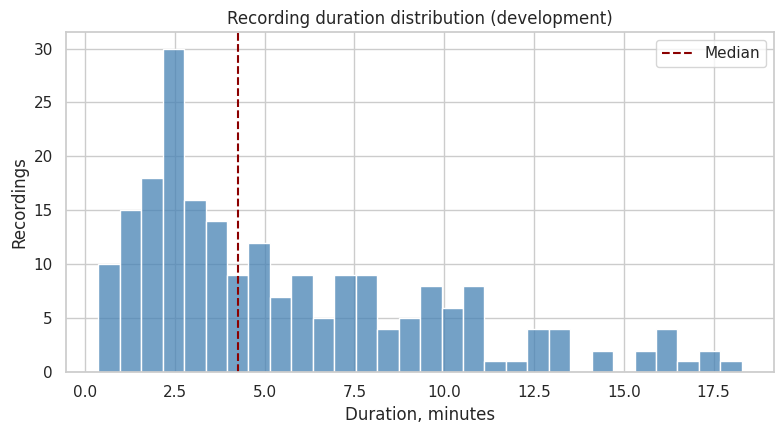

Saved: /content/drive/MyDrive/audio_curse_option2/results/eda/01_recording_duration.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(
    data=recording_stats,
    x="duration_minutes",
    bins=30,
    color="steelblue",
    edgecolor="white",
    ax=ax,
)
ax.axvline(recording_stats["duration_minutes"].median(), color="darkred", linestyle="--", label="Median")
ax.set(title="Recording duration distribution (development)", xlabel="Duration, minutes", ylabel="Recordings")
ax.legend()
fig.tight_layout()
save_figure(fig, "01_recording_duration.png")

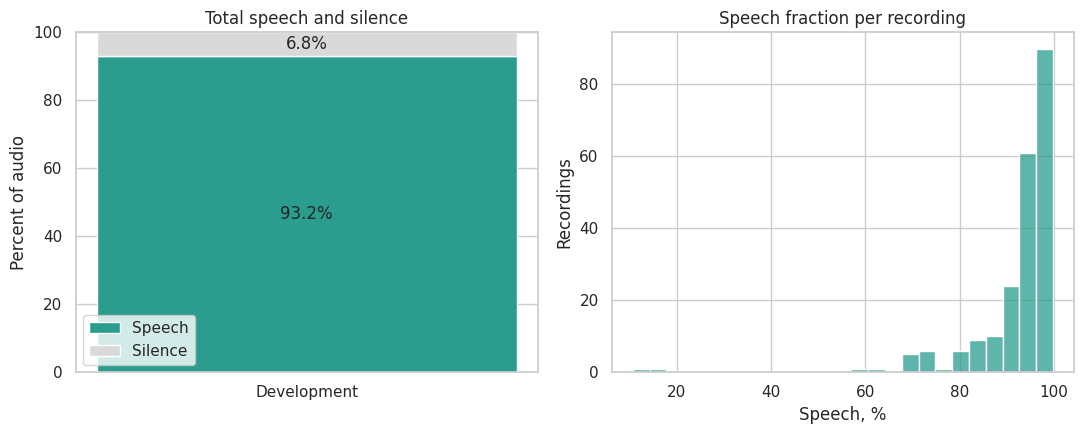

Saved: /content/drive/MyDrive/audio_curse_option2/results/eda/02_speech_silence_ratio.png


In [14]:
speech_total = recording_stats["speech_seconds"].sum()
silence_total = recording_stats["silence_seconds"].sum()
total = speech_total + silence_total
speech_percent = 100 * speech_total / total
silence_percent = 100 * silence_total / total

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(["Development"], [speech_percent], label="Speech", color="#2a9d8f")
axes[0].bar(["Development"], [silence_percent], bottom=[speech_percent], label="Silence", color="#d9d9d9")
axes[0].text(0, speech_percent / 2, f"{speech_percent:.1f}%", ha="center", va="center")
axes[0].text(0, speech_percent + silence_percent / 2, f"{silence_percent:.1f}%", ha="center", va="center")
axes[0].set(title="Total speech and silence", ylabel="Percent of audio", ylim=(0, 100))
axes[0].legend()

sns.histplot(recording_stats["speech_fraction"] * 100, bins=25, color="#2a9d8f", ax=axes[1])
axes[1].set(title="Speech fraction per recording", xlabel="Speech, %", ylabel="Recordings")
fig.tight_layout()
save_figure(fig, "02_speech_silence_ratio.png")

### Speakers and segment lengths

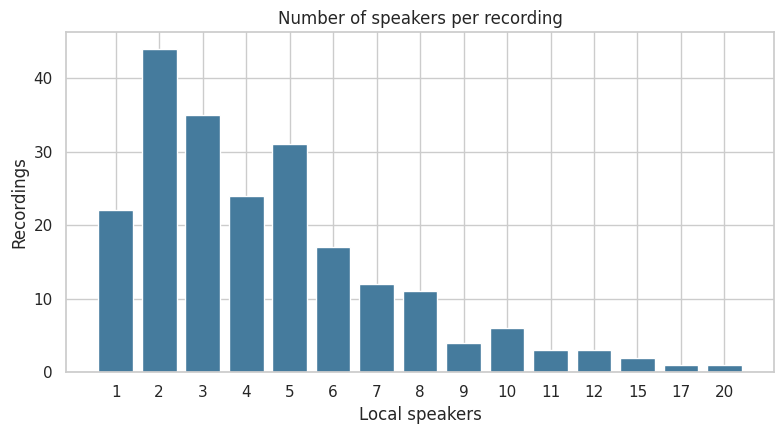

Saved: /content/drive/MyDrive/audio_curse_option2/results/eda/03_speakers_per_recording.png


In [15]:
speaker_distribution = recording_stats["num_speakers"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(speaker_distribution.index.astype(str), speaker_distribution.values, color="#457b9d")
ax.set(title="Number of speakers per recording", xlabel="Local speakers", ylabel="Recordings")
fig.tight_layout()
save_figure(fig, "03_speakers_per_recording.png")

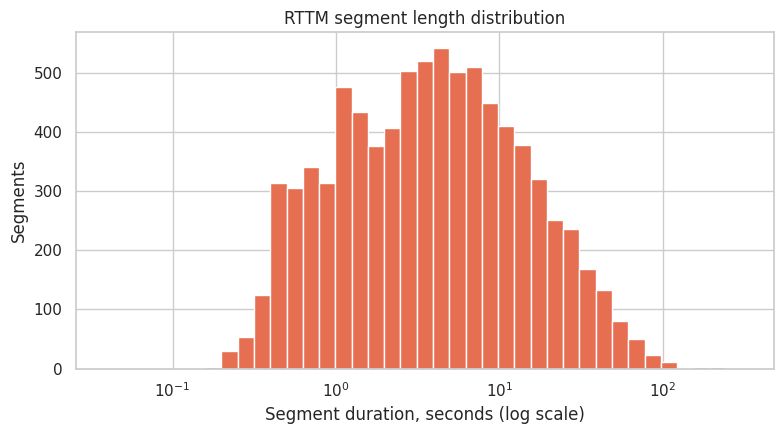

Saved: /content/drive/MyDrive/audio_curse_option2/results/eda/04_segment_lengths.png


In [16]:
segment_plot_df = eda_rttm[["duration"]].copy()
if len(segment_plot_df) > EDA_MAX_SEGMENTS:
    segment_plot_df = segment_plot_df.sample(EDA_MAX_SEGMENTS, random_state=SEED)

upper = segment_plot_df["duration"]
segment_lengths = segment_plot_df["duration"].clip(lower=0.01, upper=upper)
bins = np.logspace(np.log10(segment_lengths.min()), np.log10(segment_lengths.max()), 40)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(segment_lengths, bins=bins, color="#e76f51", edgecolor="white")
ax.set_xscale("log")
ax.set(
    title="RTTM segment length distribution",
    xlabel="Segment duration, seconds (log scale)",
    ylabel="Segments",
)
fig.tight_layout()
save_figure(fig, "04_segment_lengths.png")

### Overlapping speech and split balance

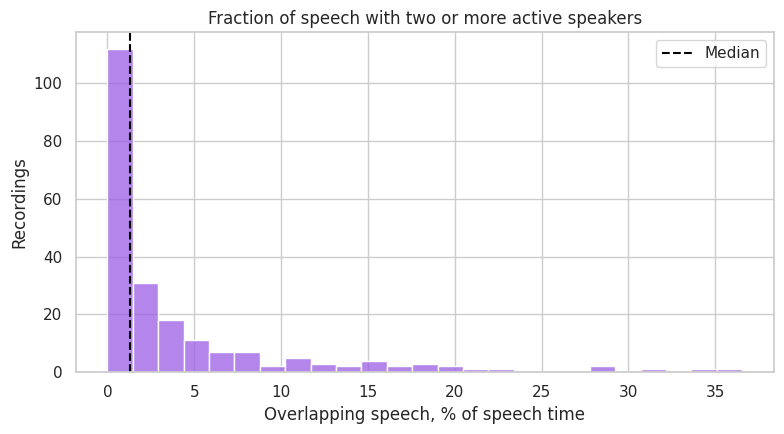

Saved: /content/drive/MyDrive/audio_curse_option2/results/eda/05_overlapping_speech.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(recording_stats["overlap_fraction"] * 100, bins=25, color="#9b5de5", ax=ax)
ax.axvline(
    recording_stats["overlap_fraction"].median() * 100,
    color="black",
    linestyle="--",
    label="Median",
)
ax.set(
    title="Fraction of speech with two or more active speakers",
    xlabel="Overlapping speech, % of speech time",
    ylabel="Recordings",
)
ax.legend()
fig.tight_layout()
save_figure(fig, "05_overlapping_speech.png")

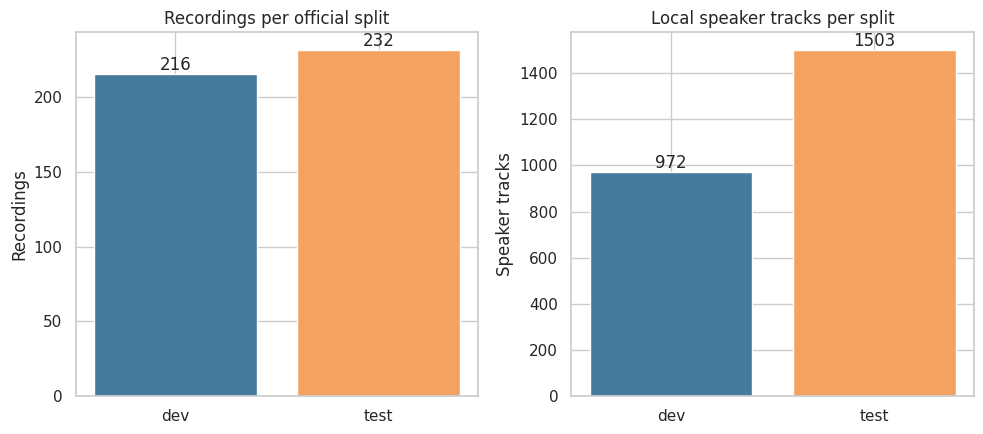

Saved: /content/drive/MyDrive/audio_curse_option2/results/eda/06_split_balance.png


,recordings,speaker_tracks
split,,
dev,216,972
test,232,1503


In [18]:
split_balance = (
    speaker_counts.groupby("split")
    .agg(recordings=("file_id", "size"), speaker_tracks=("num_speakers", "sum"))
    .reindex(["dev", "test"])
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
colors = ["#457b9d", "#f4a261"]

axes[0].bar(split_balance.index, split_balance["recordings"], color=colors)
axes[0].set(title="Recordings per official split", ylabel="Recordings")
axes[0].bar_label(axes[0].containers[0])

axes[1].bar(split_balance.index, split_balance["speaker_tracks"], color=colors)
axes[1].set(title="Local speaker tracks per split", ylabel="Speaker tracks")
axes[1].bar_label(axes[1].containers[0])

fig.tight_layout()
save_figure(fig, "06_split_balance.png")
display(split_balance)

### Example speaker timeline

Each row is one local speaker. Parallel colored segments show when speakers talk. Segments on different rows at the same time show overlapping speech.

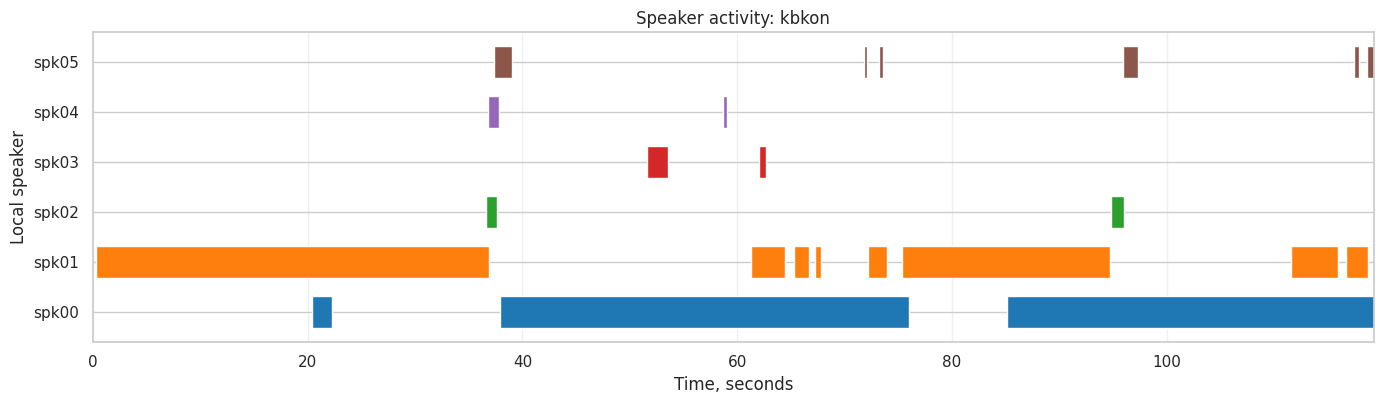

Saved: /content/drive/MyDrive/audio_curse_option2/results/eda/07_speaker_timeline_kbkon.png


In [19]:
TIMELINE_SECONDS = 120
TIMELINE_FILE_ID = None  # recording ID to draw another example.

if TIMELINE_FILE_ID is None:
    candidates = recording_stats.loc[
        (recording_stats["duration"] >= 60)
        & recording_stats["num_speakers"].between(3, 6)
    ].copy()
    if candidates.empty:
        candidates = recording_stats.copy()
    candidates["example_score"] = (candidates["duration"] - TIMELINE_SECONDS).abs()
    TIMELINE_FILE_ID = candidates.sort_values("example_score").iloc[0]["file_id"]

timeline_df = eda_rttm.loc[eda_rttm["file_id"] == TIMELINE_FILE_ID].copy()
timeline_duration = float(recording_stats.set_index("file_id").loc[TIMELINE_FILE_ID, "duration"])
window_end = min(TIMELINE_SECONDS, timeline_duration)
timeline_df = timeline_df.loc[(timeline_df["start"] < window_end) & (timeline_df["end"] > 0)]
speakers = sorted(timeline_df["speaker"].unique())
colors = sns.color_palette("tab10", n_colors=len(speakers))

fig, ax = plt.subplots(figsize=(14, max(3, 0.7 * len(speakers))))
for index, (speaker, color) in enumerate(zip(speakers, colors)):
    speaker_df = timeline_df.loc[timeline_df["speaker"] == speaker]
    bars = []
    for row in speaker_df.itertuples():
        start = max(0.0, row.start)
        end = min(window_end, row.end)
        if end > start:
            bars.append((start, end - start))
    ax.broken_barh(bars, (index - 0.32, 0.64), facecolors=color)

ax.set_yticks(range(len(speakers)), speakers)
ax.set_xlim(0, window_end)
ax.set(
    title=f"Speaker activity: {TIMELINE_FILE_ID}",
    xlabel="Time, seconds",
    ylabel="Local speaker",
)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
save_figure(fig, f"07_speaker_timeline_{TIMELINE_FILE_ID}.png")

### EDA summary

In [20]:
eda_summary = pd.DataFrame({
    "value": {
        "recordings": len(recording_stats),
        "total_audio_hours": recording_stats["duration"].sum() / 3600,
        "median_recording_minutes": recording_stats["duration_minutes"].median(),
        "speech_percent": 100 * recording_stats["speech_seconds"].sum() / recording_stats["duration"].sum(),
        "median_speakers_per_recording": recording_stats["num_speakers"].median(),
        "median_segment_seconds": eda_rttm["duration"].median(),
        "overlap_percent_of_speech": 100 * recording_stats["overlap_seconds"].sum() / recording_stats["speech_seconds"].sum(),
    }
})
eda_summary["value"] = eda_summary["value"].round(2)
eda_summary.to_csv(RESULTS_DIR / "eda_summary.csv")
display(eda_summary)
print("Plots saved in:", EDA_PLOT_DIR)

,value
recordings,216.00
total_audio_hours,20.30
median_recording_minutes,4.26
speech_percent,93.17
median_speakers_per_recording,4.00
median_segment_seconds,3.84
overlap_percent_of_speech,3.74


Plots saved in: /content/drive/MyDrive/audio_curse_option2/results/eda


## Metrics utilities

Diarization Error Rate (DER) is the main metric:

$$DER = \frac{False\ Alarm + Missed\ Speech + Speaker\ Confusion}{Reference\ Speaker\ Time}$$

- **False alarm:** speech is predicted during reference silence.
- **Miss:** reference speech is not detected.
- **Confusion:** speech is assigned to the wrong speaker.

![DER diagram](https://miro.medium.com/1*08iCugqS9zesOJ5L0k5sFQ.png)

Speaker names are arbitrary, so DER first finds the best mapping between reference and predicted speaker labels. We use no collar and we score overlapping speech. UEM files define the scored regions.

In [21]:
from pyannote.core import Annotation, Segment, Timeline
from pyannote.metrics.diarization import DiarizationErrorRate, JaccardErrorRate


def _safe_ratio(numerator, denominator):
    if denominator > 0:
        return float(numerator / denominator)
    return 0.0 if numerator == 0 else float("inf")


def jaccard_error_rate(reference, hypothesis, uem=None, collar=0.0, skip_overlap=False):
    """Return JER, which gives every reference speaker equal weight.

    JER complements DER because errors on quiet speakers are not hidden by
    one dominant speaker. Its value is between 0 and 1.
    """
    metric = JaccardErrorRate(collar=collar, skip_overlap=skip_overlap)
    return float(metric(reference, hypothesis, uem=uem))


class DiarizationScorer:
    """Accumulate DER and JER over one or more recordings."""

    def __init__(self, collar=0.0, skip_overlap=False):
        self.der_metric = DiarizationErrorRate(collar=collar, skip_overlap=skip_overlap)
        self.jer_metric = JaccardErrorRate(collar=collar, skip_overlap=skip_overlap)

    @staticmethod
    def _format_der(details):
        total = float(details["total"])
        false_alarm = float(details["false alarm"])
        miss = float(details["missed detection"])
        confusion = float(details["confusion"])
        return {
            "der": _safe_ratio(false_alarm + miss + confusion, total),
            "false_alarm_rate": _safe_ratio(false_alarm, total),
            "miss_rate": _safe_ratio(miss, total),
            "confusion_rate": _safe_ratio(confusion, total),
            "false_alarm_seconds": false_alarm,
            "miss_seconds": miss,
            "confusion_seconds": confusion,
            "reference_speaker_seconds": total,
        }

    def score(self, reference, hypothesis, uem=None):
        details = self.der_metric(reference, hypothesis, uem=uem, detailed=True)
        result = self._format_der(details)
        result["jer"] = float(self.jer_metric(reference, hypothesis, uem=uem))
        return result

    def corpus_score(self):
        result = self._format_der(self.der_metric[:])
        result["jer"] = float(abs(self.jer_metric))
        return result

    def reset(self):
        self.der_metric.reset()
        self.jer_metric.reset()

### Voice activity detection metrics

VAD ignores speaker names. False alarm rate uses non-speech time as its denominator. Miss rate uses reference speech time. F1 balances speech precision and recall.

In [22]:
from pyannote.metrics.detection import DetectionCostFunction, DetectionPrecisionRecallFMeasure


class VADScorer:
    """Compute duration-based VAD false alarm, miss, and F1."""

    def __init__(self, collar=0.0):
        self.detection = DetectionCostFunction(collar=collar, skip_overlap=False)
        self.f_measure = DetectionPrecisionRecallFMeasure(collar=collar, skip_overlap=False)

    def _format(self, detection, prf):
        precision, recall, f1 = self.f_measure.compute_metrics(detail=prf)

        speech = float(detection["positive class total"])
        non_speech = float(detection["negative class total"])
        false_alarm = float(detection["false alarm"])
        miss = float(detection["miss"])

        return {
            "false_alarm_rate": _safe_ratio(false_alarm, non_speech),
            "miss_rate": _safe_ratio(miss, speech),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "false_alarm_seconds": false_alarm,
            "miss_seconds": miss,
            "speech_seconds": speech,
            "non_speech_seconds": non_speech,
        }

    def score(self, reference, hypothesis, uem=None):
        detection = self.detection(reference, hypothesis, uem=uem, detailed=True)
        prf = self.f_measure(reference, hypothesis, uem=uem, detailed=True)
        return self._format(detection, prf)

    def corpus_score(self):
        return self._format(self.detection[:], self.f_measure[:])

    def reset(self):
        self.detection.reset()
        self.f_measure.reset()

### Speaker verification metrics

A verification trial has label 1 for the same speaker and 0 for different speakers. A larger score means that two embeddings are more similar. EER is where false accept and false reject rates are equal. minDCF finds the lowest weighted verification cost over all thresholds.

In [23]:
from sklearn.metrics import roc_curve


def _verification_roc(labels, scores):
    labels = np.asarray(labels, dtype=int).reshape(-1)
    scores = np.asarray(scores, dtype=float).reshape(-1)

    if labels.shape != scores.shape:
        raise ValueError("labels and scores must have the same length.")
    if not np.isfinite(scores).all():
        raise ValueError("scores contain NaN or infinity.")
    if set(np.unique(labels)) != {0, 1}:
        raise ValueError("labels must contain both 0 and 1.")

    false_accept, true_accept, thresholds = roc_curve(labels, scores, pos_label=1)
    false_reject = 1.0 - true_accept
    return false_accept, false_reject, thresholds


def equal_error_rate(labels, scores):
    """Return EER and its score threshold using linear ROC interpolation."""
    false_accept, false_reject, thresholds = _verification_roc(labels, scores)
    difference = false_accept - false_reject
    exact = np.flatnonzero(np.isclose(difference, 0.0))

    if len(exact):
        index = int(exact[0])
        eer = false_accept[index]
        threshold = thresholds[index]
    else:
        crossings = np.flatnonzero(difference[:-1] * difference[1:] < 0)
        if len(crossings):
            left = int(crossings[0])
            weight = abs(difference[left]) / (abs(difference[left]) + abs(difference[left + 1]))
            eer = false_accept[left] + weight * (false_accept[left + 1] - false_accept[left])
            if np.isfinite(thresholds[left]):
                threshold = thresholds[left] + weight * (thresholds[left + 1] - thresholds[left])
            else:
                threshold = thresholds[left + 1]
        else:
            index = int(np.argmin(np.abs(difference)))
            eer = 0.5 * (false_accept[index] + false_reject[index])
            threshold = thresholds[index]

    return {"eer": float(eer), "threshold": float(threshold)}


def minimum_detection_cost(
    labels,
    scores,
    p_target=0.01,
    cost_miss=1.0,
    cost_false_alarm=1.0,
):
    """Return normalized minDCF and the best verification threshold."""
    if not 0 < p_target < 1:
        raise ValueError("p_target must be between 0 and 1.")

    false_accept, false_reject, thresholds = _verification_roc(labels, scores)
    costs = (
        cost_miss * p_target * false_reject
        + cost_false_alarm * (1.0 - p_target) * false_accept
    )
    index = int(np.argmin(costs))
    default_cost = min(cost_miss * p_target, cost_false_alarm * (1.0 - p_target))

    return {
        "min_dcf": float(costs[index] / default_cost),
        "raw_cost": float(costs[index]),
        "threshold": float(thresholds[index]),
    }

### Synthetic metric test

The hypothesis has one second of speaker confusion, one second of missed speech, and one second of false alarm. Therefore, expected DER is $3/8 = 0.375$.

In [24]:
reference = Annotation(uri="synthetic")
reference[Segment(0, 4)] = "A"
reference[Segment(4, 8)] = "B"

hypothesis = Annotation(uri="synthetic")
hypothesis[Segment(0, 3)] = "X"
hypothesis[Segment(3, 7)] = "Y"
hypothesis[Segment(8, 9)] = "Z"

synthetic_uem = Timeline([Segment(0, 10)], uri="synthetic")

diarization_test = DiarizationScorer().score(reference, hypothesis, uem=synthetic_uem)
vad_test = VADScorer().score(reference, hypothesis, uem=synthetic_uem)
eer_test = equal_error_rate([1, 1, 0, 0], [0.9, 0.8, 0.2, 0.1])
dcf_test = minimum_detection_cost([1, 1, 0, 0], [0.9, 0.8, 0.2, 0.1])

assert np.isclose(diarization_test["false_alarm_seconds"], 1.0)
assert np.isclose(diarization_test["miss_seconds"], 1.0)
assert np.isclose(diarization_test["confusion_seconds"], 1.0)
assert np.isclose(diarization_test["der"], 3 / 8)
assert np.isclose(diarization_test["jer"], 0.325)

assert np.isclose(vad_test["false_alarm_rate"], 1 / 2)
assert np.isclose(vad_test["miss_rate"], 1 / 8)
assert np.isclose(vad_test["f1"], 7 / 8)

assert np.isclose(eer_test["eer"], 0.0)
assert np.isclose(dcf_test["min_dcf"], 0.0)

display(pd.DataFrame({
    "DER test": diarization_test,
    "VAD test": vad_test,
}).T)
print("EER test:", eer_test)
print("minDCF test:", dcf_test)
print("All metric tests passed.")

,der,false_alarm_rate,miss_rate,confusion_rate,false_alarm_seconds,miss_seconds,confusion_seconds,reference_speaker_seconds,jer,precision,recall,f1,speech_seconds,non_speech_seconds
DER test,0.375,0.125,0.125,0.125,1.0,1.0,1.0,8.0,0.325,NaN,NaN,NaN,NaN,NaN
VAD test,NaN,0.500,0.125,NaN,1.0,1.0,NaN,NaN,NaN,0.875,0.875,0.875,8.0,2.0


EER test: {'eer': 0.0, 'threshold': 0.8}
minDCF test: {'min_dcf': 0.0, 'raw_cost': 0.0, 'threshold': 0.8}
All metric tests passed.


## Track A: pyannote baseline

Pretrained `pyannote/speaker-diarization-3.1` pipeline without fine-tuning

In [25]:
from getpass import getpass


def read_hf_token():
    token = os.environ.get("HF_TOKEN")

    if not token and IN_COLAB:
        try:
            from google.colab import userdata
            token = userdata.get("HF_TOKEN")
        except Exception:
            pass

    if not token and IN_KAGGLE:
        try:
            from kaggle_secrets import UserSecretsClient
            token = UserSecretsClient().get_secret("HF_TOKEN")
        except Exception:
            pass

    if not token:
        token = getpass("Hugging Face read token: ").strip()
    if not token:
        raise RuntimeError("HF_TOKEN is required for the gated pyannote models.")
    return token


HF_TOKEN = read_hf_token()
print("Hugging Face token ready!")

Hugging Face token ready!


In [26]:
from pyannote.audio import Pipeline

PYANNOTE_PIPELINE_ID = "pyannote/speaker-diarization-3.1"
PYANNOTE_CACHE_DIR = WORK_DIR / "pyannote_models"
PYANNOTE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

baseline_pipeline = Pipeline.from_pretrained(
    PYANNOTE_PIPELINE_ID,
    use_auth_token=HF_TOKEN,
    cache_dir=PYANNOTE_CACHE_DIR,
)

if baseline_pipeline is None:
    raise RuntimeError("Could not load the pipeline. Check the token and accept both model conditions.")

baseline_pipeline.to(DEVICE)

# Batch pyannote's internal audio chunks. Recordings still run one by one
# because speaker clustering is independent for every recording.
PYANNOTE_SEGMENTATION_BATCH_SIZE = 32 if DEVICE.type == "cuda" else 1
PYANNOTE_EMBEDDING_BATCH_SIZE = 32 if DEVICE.type == "cuda" else 1
baseline_pipeline.segmentation_batch_size = PYANNOTE_SEGMENTATION_BATCH_SIZE
baseline_pipeline.embedding_batch_size = PYANNOTE_EMBEDDING_BATCH_SIZE

print("Pipeline:", PYANNOTE_PIPELINE_ID)
print("Inference device:", DEVICE)
print("Segmentation batch size:", baseline_pipeline.segmentation_batch_size)
print("Embedding batch size:", baseline_pipeline.embedding_batch_size)

pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

config.yaml:   0%|          | 0.00/399 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


pytorch_model.bin:   0%|          | 0.00/26.6M [00:00<?, ?B/s]

config.yaml:   0%|          | 0.00/221 [00:00<?, ?B/s]

Pipeline: pyannote/speaker-diarization-3.1
Inference device: cuda
Segmentation batch size: 32
Embedding batch size: 32


### Small validation subset

The selected IDs are saved and reused. Step 3 must keep these recordings outside the future training set. The five-minute limit keeps this first GPU run short.

In [27]:
BASELINE_NUM_FILES = 3
BASELINE_MAX_MINUTES = 5
BASELINE_IDS_PATH = MANIFEST_DIR / "pyannote_baseline_validation_ids.txt"

development_by_id = {file["uri"]: file for file in development_files}
short_dev_ids = sorted(
    recordings_df.loc[
        (recordings_df["split"] == "dev")
        & recordings_df["exists"]
        & (recordings_df["duration"] <= BASELINE_MAX_MINUTES * 60),
        "file_id",
    ]
)

if BASELINE_IDS_PATH.exists():
    baseline_validation_ids = [line for line in BASELINE_IDS_PATH.read_text().splitlines() if line]
else:
    rng = np.random.default_rng(SEED)
    baseline_validation_ids = sorted(
        rng.choice(short_dev_ids, size=min(BASELINE_NUM_FILES, len(short_dev_ids)), replace=False).tolist()
    )
    BASELINE_IDS_PATH.write_text("\n".join(baseline_validation_ids) + "\n")

unknown_ids = set(baseline_validation_ids) - set(development_by_id)
if unknown_ids:
    raise RuntimeError(f"Unknown validation IDs: {sorted(unknown_ids)}")

baseline_validation_files = [development_by_id[file_id] for file_id in baseline_validation_ids]
display(
    recordings_df.loc[recordings_df["file_id"].isin(baseline_validation_ids), ["file_id", "duration"]]
    .assign(duration_minutes=lambda frame: frame["duration"] / 60)
    [["file_id", "duration_minutes"]]
)
print("Saved subset:", BASELINE_IDS_PATH)

,file_id,duration_minutes
59,gwtwd,0.8876
60,gzvkx,3.7536
110,mjgil,3.4592


Saved subset: /content/drive/MyDrive/audio_curse_option2/manifests/pyannote_baseline_validation_ids.txt


### Baseline inference and DER

In [28]:
from time import perf_counter


BASELINE_DIR = RESULTS_DIR / "track_a_baseline"
BASELINE_RTTM_DIR = BASELINE_DIR / "rttm"
BASELINE_RTTM_DIR.mkdir(parents=True, exist_ok=True)

baseline_scorer = DiarizationScorer(collar=0.0, skip_overlap=False)
baseline_hypotheses = {}
baseline_rows = []
baseline_errors = []

for file in tqdm(baseline_validation_files, desc="pyannote baseline"):
    file_id = file["uri"]
    try:
        start_time = perf_counter()
        # Pass audio from soundfile to avoid removed TorchAudio I/O APIs.
        audio, sample_rate = sf.read(file["audio"], dtype="float32", always_2d=True)
        waveform = torch.from_numpy(audio.T).contiguous()
        with torch.inference_mode():
            hypothesis = baseline_pipeline({"waveform": waveform, "sample_rate": sample_rate})
        inference_seconds = perf_counter() - start_time

        reference = file["annotation"]
        uem = file["annotated"]
        scores = baseline_scorer.score(reference, hypothesis, uem=uem)
        audio_seconds = float(uem.duration())

        hypothesis.uri = file_id
        with (BASELINE_RTTM_DIR / f"{file_id}.rttm").open("w") as rttm_file:
            hypothesis.write_rttm(rttm_file)

        baseline_hypotheses[file_id] = hypothesis
        baseline_rows.append({
            "file_id": file_id,
            "audio_seconds": audio_seconds,
            "reference_speakers": len(reference.labels()),
            "predicted_speakers": len(hypothesis.labels()),
            "inference_seconds": inference_seconds,
            "real_time_factor": inference_seconds / audio_seconds,
            **scores,
        })
    except Exception as error:
        baseline_errors.append({"file_id": file_id, "error": repr(error)})
        print(f"Failed {file_id}: {error}")

if not baseline_rows:
    raise RuntimeError("Baseline inference failed for every recording.")

baseline_results_df = pd.DataFrame(baseline_rows).sort_values("der").reset_index(drop=True)
baseline_results_df.to_csv(BASELINE_DIR / "per_file_results.csv", index=False)

if baseline_errors:
    pd.DataFrame(baseline_errors).to_csv(BASELINE_DIR / "errors.csv", index=False)

component_sum = (
    baseline_results_df["false_alarm_rate"]
    + baseline_results_df["miss_rate"]
    + baseline_results_df["confusion_rate"]
)
assert np.allclose(baseline_results_df["der"], component_sum)

display(
    baseline_results_df.style.format({
        "der": "{:.2%}",
        "jer": "{:.2%}",
        "false_alarm_rate": "{:.2%}",
        "miss_rate": "{:.2%}",
        "confusion_rate": "{:.2%}",
        "real_time_factor": "{:.2f}",
    })
)

pyannote baseline:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pyannote/audio/utils/reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
It can be re-enabled by calling
   >>> import torch
   >>> torch.backends.cuda.matmul.allow_tf32 = True
   >>> torch.backends.cudnn.allow_tf32 = True
See https://github.com/pyannote/pyannote-audio/issues/1370 for more details.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:104: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1823.)
  std = sequences.std(dim=-1, correction=1)


,file_id,audio_seconds,reference_speakers,predicted_speakers,inference_seconds,real_time_factor,der,false_alarm_rate,miss_rate,confusion_rate,false_alarm_seconds,miss_seconds,confusion_seconds,reference_speaker_seconds,jer
0,mjgil,207.552000,2,2,8.813024,0.04,2.23%,1.77%,0.38%,0.08%,3.543000,0.763625,0.168750,200.480000,2.60%
1,gzvkx,225.216000,6,4,9.501016,0.04,4.99%,1.41%,1.17%,2.42%,3.249219,2.696062,5.584719,230.960000,36.88%
2,gwtwd,53.256000,4,5,4.201161,0.08,16.87%,3.68%,5.22%,7.97%,2.257187,3.203406,4.891250,61.360000,26.57%


In [29]:
baseline_summary = baseline_scorer.corpus_score()
baseline_summary = {
    **baseline_summary,
    "pipeline": PYANNOTE_PIPELINE_ID,
    "num_files": int(len(baseline_results_df)),
    "mean_file_der": float(baseline_results_df["der"].mean()),
    "total_audio_minutes": float(baseline_results_df["audio_seconds"].sum() / 60),
    "mean_real_time_factor": float(baseline_results_df["real_time_factor"].mean()),
}
baseline_summary_df = pd.DataFrame([baseline_summary])
baseline_summary_df.to_csv(BASELINE_DIR / "summary.csv", index=False)

display(
    baseline_summary_df.style.format({
        "der": "{:.2%}",
        "jer": "{:.2%}",
        "false_alarm_rate": "{:.2%}",
        "miss_rate": "{:.2%}",
        "confusion_rate": "{:.2%}",
        "mean_file_der": "{:.2%}",
    })
)
print("Saved baseline results in:", BASELINE_DIR)

,der,false_alarm_rate,miss_rate,confusion_rate,false_alarm_seconds,miss_seconds,confusion_seconds,reference_speaker_seconds,jer,pipeline,num_files,mean_file_der,total_audio_minutes,mean_real_time_factor
0,5.35%,1.84%,1.35%,2.16%,9.049406,6.663094,10.644719,492.800000,27.73%,pyannote/speaker-diarization-3.1,3,8.03%,8.100400,0.054511


Saved baseline results in: /content/drive/MyDrive/audio_curse_option2/results/track_a_baseline


### Reference and hypothesis example

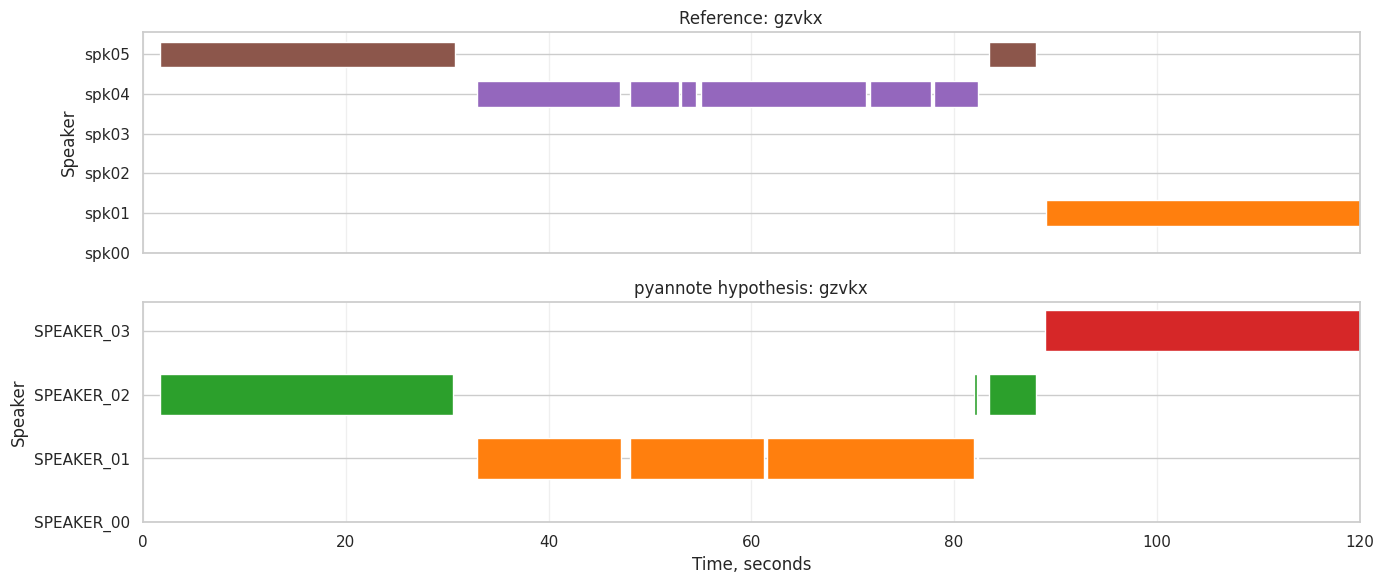

Saved: /content/drive/MyDrive/audio_curse_option2/results/track_a_baseline/reference_vs_hypothesis_gzvkx.png


In [30]:
def plot_annotation_timeline(ax, annotation, window, title):
    labels = sorted(annotation.labels(), key=str)
    colors = sns.color_palette("tab10", n_colors=max(1, len(labels)))

    for index, (label, color) in enumerate(zip(labels, colors)):
        bars = []
        for segment in annotation.label_timeline(label).crop(window):
            bars.append((segment.start, segment.duration))
        ax.broken_barh(bars, (index - 0.32, 0.64), facecolors=color)

    ax.set_yticks(range(len(labels)), [str(label) for label in labels])
    ax.set_xlim(window.start, window.end)
    ax.set(title=title, ylabel="Speaker")
    ax.grid(axis="x", alpha=0.3)


middle_index = len(baseline_results_df) // 2
example_id = baseline_results_df.iloc[middle_index]["file_id"]
example_file = development_by_id[example_id]
example_reference = example_file["annotation"]
example_hypothesis = baseline_hypotheses[example_id]
example_extent = example_file["annotated"].extent()
example_window = Segment(example_extent.start, min(example_extent.start + 120, example_extent.end))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
plot_annotation_timeline(axes[0], example_reference, example_window, f"Reference: {example_id}")
plot_annotation_timeline(axes[1], example_hypothesis, example_window, f"pyannote hypothesis: {example_id}")
axes[1].set_xlabel("Time, seconds")
fig.tight_layout()

baseline_plot_path = BASELINE_DIR / f"reference_vs_hypothesis_{example_id}.png"
fig.savefig(baseline_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", baseline_plot_path)

### Frozen baseline on the official test set

This runs the unchanged pretrained pipeline on all 232 test recordings. It saves every RTTM and metric row immediately, so rerunning the cell continues after a timeout. Scoring uses a zero-second collar and includes overlapping speech.

This is the final baseline result. Do not use test scores to tune later models. Training choices and pipeline thresholds must use only the development validation split.

In [31]:
TEST_BASELINE_DIR = RESULTS_DIR / "track_a_baseline_test"
TEST_BASELINE_RTTM_DIR = TEST_BASELINE_DIR / "rttm"
TEST_RESULTS_PATH = TEST_BASELINE_DIR / "per_file_results.csv"
TEST_ERRORS_PATH = TEST_BASELINE_DIR / "errors.csv"
TEST_SUMMARY_PATH = TEST_BASELINE_DIR / "summary.csv"
TEST_BASELINE_RTTM_DIR.mkdir(parents=True, exist_ok=True)

TEST_EXPECTED_FILES = 232
TEST_COLLAR = 0.0
TEST_SKIP_OVERLAP = False
test_eval_files = sorted(test_files, key=lambda file: file["uri"])

if len(test_eval_files) != TEST_EXPECTED_FILES:
    raise RuntimeError(f"Expected {TEST_EXPECTED_FILES} test files, found {len(test_eval_files)}.")

missing_test_audio = [
    file["uri"] for file in test_eval_files if not Path(file["audio"]).is_file()
]
if missing_test_audio:
    raise FileNotFoundError(
        f"Missing {len(missing_test_audio)} test WAV files. "
        "Set DOWNLOAD_TEST_AUDIO=True and rerun the Step 2 download and UEM cells."
    )

test_manifest = recordings_df.loc[recordings_df["split"] == "test"]
bad_test_uem = test_manifest.loc[test_manifest["uem_source"] != "audio"]
if len(bad_test_uem):
    raise RuntimeError("Test UEM must use WAV duration. Rerun the Step 2 UEM cell.")


def save_csv_atomic(frame, path):
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temporary_path, index=False)
    temporary_path.replace(path)


if TEST_RESULTS_PATH.exists():
    saved_test_results = pd.read_csv(TEST_RESULTS_PATH)
    test_result_rows = saved_test_results.set_index("file_id").to_dict("index")
else:
    test_result_rows = {}

if TEST_ERRORS_PATH.exists():
    saved_test_errors = pd.read_csv(TEST_ERRORS_PATH)
    test_error_rows = saved_test_errors.set_index("file_id").to_dict("index")
else:
    test_error_rows = {}

completed_test_ids = {
    file_id for file_id in test_result_rows
    if (TEST_BASELINE_RTTM_DIR / f"{file_id}.rttm").is_file()
}
print(f"Already completed: {len(completed_test_ids)}/{TEST_EXPECTED_FILES}")
print("Results directory:", TEST_BASELINE_DIR)

Already completed: 232/232
Results directory: /content/drive/MyDrive/audio_curse_option2/results/track_a_baseline_test


In [32]:
from time import perf_counter
import warnings


pending_test_files = [
    file for file in test_eval_files if file["uri"] not in completed_test_ids
]

warnings.filterwarnings(
    "ignore",
    message=r'Existing precomputed key "annotation" has been modified by a preprocessor\.',
    category=UserWarning,
    module=r"pyannote\.database\.protocol\.protocol",
)

print(f"Pending recordings: {len(pending_test_files)}")
print(
    f"Internal batches: segmentation={baseline_pipeline.segmentation_batch_size}, "
    f"embedding={baseline_pipeline.embedding_batch_size}"
)

progress_state = {"last_refresh": 0.0, "last_message": 0.0}

with tqdm(
    total=len(pending_test_files),
    desc="pyannote official test",
    unit="file",
    dynamic_ncols=True,
) as file_progress:
  for file in pending_test_files:
    file_id = file["uri"]
    audio = waveform = hypothesis = None
    progress_state["last_refresh"] = 0.0
    progress_state["last_message"] = 0.0

    def show_internal_progress(step_name, step_artifact, completed=None, total=None, **kwargs):
        now = perf_counter()
        if now - progress_state["last_refresh"] < 0.5 and completed != total:
            return
        progress_state["last_refresh"] = now
        step_progress = f" {completed}/{total}" if total else ""
        file_progress.set_postfix_str(
            f"{file_id}: {step_name}{step_progress}", refresh=True
        )
        if now - progress_state["last_message"] >= 30 or completed == total:
            progress_state["last_message"] = now
            tqdm.write(
                f"[{len(completed_test_ids)}/{TEST_EXPECTED_FILES}] working on "
                f"{file_id}: {step_name}{step_progress}"
            )

    try:
        start_time = perf_counter()
        audio, sample_rate = sf.read(file["audio"], dtype="float32", always_2d=True)
        waveform = torch.from_numpy(audio.T).contiguous()

        with torch.inference_mode():
            hypothesis = baseline_pipeline(
                {"waveform": waveform, "sample_rate": sample_rate},
                hook=show_internal_progress,
            )

        inference_seconds = perf_counter() - start_time
        reference = file["annotation"]
        uem = file["annotated"]
        scorer = DiarizationScorer(collar=TEST_COLLAR, skip_overlap=TEST_SKIP_OVERLAP)
        scores = scorer.score(reference, hypothesis, uem=uem)
        audio_seconds = float(uem.duration())

        hypothesis.uri = file_id
        rttm_path = TEST_BASELINE_RTTM_DIR / f"{file_id}.rttm"
        temporary_rttm = rttm_path.with_suffix(".rttm.tmp")
        with temporary_rttm.open("w") as rttm_file:
            hypothesis.write_rttm(rttm_file)
        temporary_rttm.replace(rttm_path)

        test_result_rows[file_id] = {
            "audio_seconds": audio_seconds,
            "reference_speakers": len(reference.labels()),
            "predicted_speakers": len(hypothesis.labels()),
            "inference_seconds": inference_seconds,
            "real_time_factor": inference_seconds / audio_seconds,
            **scores,
        }
        test_error_rows.pop(file_id, None)
        completed_test_ids.add(file_id)

        result_frame = (
            pd.DataFrame.from_dict(test_result_rows, orient="index")
            .rename_axis("file_id")
            .reset_index()
            .sort_values("file_id")
        )
        save_csv_atomic(result_frame, TEST_RESULTS_PATH)

        if test_error_rows:
            error_frame = (
                pd.DataFrame.from_dict(test_error_rows, orient="index")
                .rename_axis("file_id")
                .reset_index()
                .sort_values("file_id")
            )
            save_csv_atomic(error_frame, TEST_ERRORS_PATH)
        else:
            TEST_ERRORS_PATH.unlink(missing_ok=True)

        tqdm.write(
            f"[{len(completed_test_ids)}/{TEST_EXPECTED_FILES}] {file_id}: "
            f"DER={scores['der']:.2%}, time={inference_seconds / 60:.1f} min"
        )

    except Exception as error:
        test_error_rows[file_id] = {"error": repr(error)}
        error_frame = (
            pd.DataFrame.from_dict(test_error_rows, orient="index")
            .rename_axis("file_id")
            .reset_index()
            .sort_values("file_id")
        )
        save_csv_atomic(error_frame, TEST_ERRORS_PATH)
        tqdm.write(f"Failed {file_id}: {error}")

    finally:
        del audio, waveform, hypothesis
        file_progress.update(1)

completed_now = sum(
    (TEST_BASELINE_RTTM_DIR / f"{file_id}.rttm").is_file()
    for file_id in test_result_rows
)
print(f"Completed: {completed_now}/{TEST_EXPECTED_FILES}")
if completed_now < TEST_EXPECTED_FILES:
    print("Rerun this cell to retry failures or continue after a timeout.")

Pending recordings: 0
Internal batches: segmentation=32, embedding=32


pyannote official test: 0file [00:00, ?file/s]

Completed: 232/232


In [33]:
from pyannote.database.util import load_rttm


if not TEST_RESULTS_PATH.exists():
    raise RuntimeError("Run the official test inference cell first.")

stored_results = pd.read_csv(TEST_RESULTS_PATH).set_index("file_id").to_dict("index")
test_corpus_scorer = DiarizationScorer(collar=TEST_COLLAR, skip_overlap=TEST_SKIP_OVERLAP)
rescored_rows = []

for file in tqdm(test_eval_files, desc="Score saved test RTTMs"):
    file_id = file["uri"]
    rttm_path = TEST_BASELINE_RTTM_DIR / f"{file_id}.rttm"
    if not rttm_path.is_file():
        continue

    hypothesis = load_rttm(rttm_path)[file_id]
    reference = file["annotation"]
    uem = file["annotated"]
    scores = test_corpus_scorer.score(reference, hypothesis, uem=uem)
    saved = stored_results.get(file_id, {})
    audio_seconds = float(uem.duration())
    inference_seconds = float(saved.get("inference_seconds", np.nan))

    rescored_rows.append({
        "file_id": file_id,
        "audio_seconds": audio_seconds,
        "reference_speakers": len(reference.labels()),
        "predicted_speakers": len(hypothesis.labels()),
        "inference_seconds": inference_seconds,
        "real_time_factor": inference_seconds / audio_seconds,
        **scores,
    })

if not rescored_rows:
    raise RuntimeError("No saved test RTTMs were found.")

test_baseline_results_df = pd.DataFrame(rescored_rows).sort_values("file_id").reset_index(drop=True)
save_csv_atomic(test_baseline_results_df, TEST_RESULTS_PATH)

component_sum = (
    test_baseline_results_df["false_alarm_rate"]
    + test_baseline_results_df["miss_rate"]
    + test_baseline_results_df["confusion_rate"]
)
assert np.allclose(test_baseline_results_df["der"], component_sum)

test_baseline_summary = {
    **test_corpus_scorer.corpus_score(),
    "pipeline": PYANNOTE_PIPELINE_ID,
    "split": "official_test",
    "status": "complete" if len(test_baseline_results_df) == TEST_EXPECTED_FILES else "partial",
    "num_files": int(len(test_baseline_results_df)),
    "expected_files": TEST_EXPECTED_FILES,
    "collar_seconds": TEST_COLLAR,
    "overlap_scored": not TEST_SKIP_OVERLAP,
    "mean_file_der": float(test_baseline_results_df["der"].mean()),
    "total_audio_hours": float(test_baseline_results_df["audio_seconds"].sum() / 3600),
    "mean_real_time_factor": float(test_baseline_results_df["real_time_factor"].mean()),
}
test_baseline_summary_df = pd.DataFrame([test_baseline_summary])
save_csv_atomic(test_baseline_summary_df, TEST_SUMMARY_PATH)

display(
    test_baseline_summary_df.style.format({
        "der": "{:.2%}",
        "jer": "{:.2%}",
        "false_alarm_rate": "{:.2%}",
        "miss_rate": "{:.2%}",
        "confusion_rate": "{:.2%}",
        "mean_file_der": "{:.2%}",
    })
)
print("Saved per-file metrics:", TEST_RESULTS_PATH)
print("Saved corpus metrics:", TEST_SUMMARY_PATH)

if len(test_baseline_results_df) == TEST_EXPECTED_FILES:
    print("Official test baseline is complete and frozen.")
else:
    print("Partial result only. Rerun inference before reporting this score.")

Score saved test RTTMs:   0%|          | 0/232 [00:00<?, ?it/s]

,der,false_alarm_rate,miss_rate,confusion_rate,false_alarm_seconds,miss_seconds,confusion_seconds,reference_speaker_seconds,jer,pipeline,split,status,num_files,expected_files,collar_seconds,overlap_scored,mean_file_der,total_audio_hours,mean_real_time_factor
0,11.18%,4.08%,3.38%,3.72%,5904.409000,4897.428000,5385.186000,144790.608000,34.79%,pyannote/speaker-diarization-3.1,official_test,complete,232,232,0.000000,True,12.19%,43.536142,0.048280


Saved per-file metrics: /content/drive/MyDrive/audio_curse_option2/results/track_a_baseline_test/per_file_results.csv
Saved corpus metrics: /content/drive/MyDrive/audio_curse_option2/results/track_a_baseline_test/summary.csv
Official test baseline is complete and frozen.
